# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [42]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [44]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [45]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


El conjunto de datos contiene 40.000 registros y 9 variables. No se observan valores ausentes, ya que todas las columnas tienen 40.000 valores no nulos. Las variables categóricas (user_id, date, landing, region, dispositivo, traffic_source y user_type) fueron cargadas como tipo object, mientras que converted es una variable binaria de tipo int64 y gasto es una variable numérica de tipo float64. A primera vista no se identifican problemas de calidad de datos, por lo que se puede continuar con el análisis exploratorio y la validación del experimento.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [46]:
df['user_id'].nunique()

40000

In [47]:
print('Usuarios únicos:', df['user_id'].nunique())
print('Total registros:', len(df))

Usuarios únicos: 40000
Total registros: 40000


Se verificó que existen 40.000 usuarios únicos y 40.000 registros en el dataset. Esto indica que cada fila representa un usuario distinto y no se identifican duplicados en la variable user_id. Por lo tanto, se cumple el supuesto de independencia de las observaciones y se puede continuar con el análisis del experimento A/B.

 **Variable `date`**  
Explorar rango de fechas

In [48]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [49]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [50]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [51]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [52]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


Se verificó la consistencia de las variables clave del experimento. La variable date contiene registros correspondientes a un período de 28 días, entre el 01 y el 28 de enero de 2026, sin evidencias de fechas fuera del rango esperado. La variable gasto presenta una alta proporción de valores iguales a cero, lo cual es consistente con la definición del negocio, ya que los usuarios que no convierten no generan gasto. Al analizar únicamente los usuarios convertidos, se observa un gasto promedio de 65.37 unidades monetarias, con valores comprendidos entre 12.12 y 303.68. Finalmente, la variable landing contiene únicamente las categorías esperadas (A y B) y presenta una distribución equilibrada entre ambos grupos (19.982 usuarios en A y 20.018 en B), lo que favorece la validez de las comparaciones estadísticas posteriores. No se identifican anomalías ni categorías inesperadas, por lo que se puede continuar con el análisis del experimento.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [53]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [54]:
print("Gasto promedio A:", gasto_A.mean())
print("Gasto promedio B:", gasto_B.mean())

Gasto promedio A: 61.0865724522293
Gasto promedio B: 68.74536005009392


In [55]:
gasto_A.describe()

count    2512.000000
mean       61.086572
std        28.875470
min        12.120000
25%        40.612500
50%        55.840000
75%        74.837500
max       303.680000
Name: gasto, dtype: float64

In [56]:
gasto_B.describe()

count    3194.00000
mean       68.74536
std        32.00102
min        12.98000
25%        45.21000
50%        62.57000
75%        84.27750
max       249.99000
Name: gasto, dtype: float64

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.

In [57]:
from scipy.stats import ttest_ind

In [58]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.36563589591332
Valor p: 1.0635288333792346e-20


In [59]:
print("Media gasto A:", gasto_A.mean())
print("Media gasto B:", gasto_B.mean())

Media gasto A: 61.0865724522293
Media gasto B: 68.74536005009392


### 📝 Conclusión e interpretación

Se aplicó una prueba t para comparar el gasto promedio de los usuarios convertidos entre las versiones A y B de la página de inicio. El estadístico obtenido fue t = -9.37 y el valor p fue 1.06 × 10⁻²⁰, muy inferior al nivel de significancia de 0.05. Por lo tanto, se rechaza la hipótesis nula y se concluye que existe una diferencia estadísticamente significativa en el gasto promedio entre ambas versiones. El signo negativo del estadístico sugiere que el gasto promedio de los usuarios de la versión B es superior al de la versión A. Este resultado indica que la versión B podría generar un mayor valor económico para el negocio, aunque es recomendable complementar el análisis con la comparación de medias y la tasa de conversión antes de emitir una recomendación final.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** La tasa de conversión es la misma para las páginas A y B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre las páginas A y B.

In [60]:
# Número de usuarios convertidos por página
convertidos = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()

print("Usuarios convertidos por página:\n", convertidos)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [61]:
from statsmodels.stats.proportion import proportions_ztest

# Aplicar prueba
conteos = [convertidos['A'], convertidos['B']]
observaciones = [totales['A'], totales['B']]

z_stat, p_value = proportions_ztest(conteos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (3.76 × 10⁻²²) es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula. Existe evidencia estadística suficiente para afirmar que la tasa de conversión difiere entre las páginas A y B.

**Interpretación de negocio:**  
Los resultados indican que la versión de la página mostrada a los usuarios influye en la probabilidad de conversión. La diferencia observada entre las tasas de conversión de las páginas A y B es estadísticamente significativa y difícilmente puede atribuirse al azar. Además, la página B registró un mayor número de conversiones (3.194) que la página A (2.512), por lo que presenta un mejor desempeño para transformar visitantes en clientes. Este hallazgo sugiere que la versión B sería una mejor candidata para su implementación, aunque la decisión final debe complementarse con el análisis del gasto promedio y los resultados por segmento de usuarios.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre la fuente de tráfico y la conversión. La conversión es independiente del canal de adquisición.
- **Hipótesis alternativa (H₁):** Existe una asociación entre la fuente de tráfico y la conversión. La conversión depende del canal de adquisición.

In [62]:
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])

print(tabla_trafico)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [63]:
# Aplicar prueba

from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")

Estadístico chi-cuadrado: 8.662108841397938
Valor p: 0.0341375947833914


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (0.0341) es menor que el nivel de significancia de 0.05, se rechaza la hipótesis nula. Existe evidencia estadística suficiente para concluir que la conversión está asociada con la fuente de tráfico.

**Interpretación de negocio:**  
Los resultados indican que el canal por el que llegan los usuarios influye en la probabilidad de conversión. La diferencia observada entre las fuentes de tráfico no parece deberse al azar. En términos absolutos, el canal Organic generó el mayor número de conversiones (2.480), seguido por Ads (1.759), Email (918) y Referral (549). Sin embargo, para identificar cuál canal es más eficiente, es recomendable complementar el análisis con las tasas de conversión de cada fuente de tráfico, ya que un mayor volumen de conversiones puede estar asociado a un mayor volumen de usuarios y no necesariamente a una mayor efectividad del canal.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe asociación entre el tipo de usuario y la conversión. La conversión es independiente de si el usuario es nuevo o recurrente.
- **Hipótesis alternativa (H₁):** Existe una asociación entre el tipo de usuario y la conversión. La conversión depende del tipo de usuario.

In [64]:
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])

print(tabla_usuario)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [65]:
print(pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
) * 100)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [66]:
# Aplicar prueba

from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

print(f"Estadístico chi-cuadrado: {chi2_stat}")
print(f"Valor p: {p_value}")

Estadístico chi-cuadrado: 0.5134849494478645
Valor p: 0.4736341272301974


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (0.474) es mayor que el nivel de significancia de 0.05, no rechazamos la hipótesis nula. No existe evidencia estadística suficiente para afirmar que la conversión depende del tipo de usuario.

**Interpretación de negocio:**  
Los resultados sugieren que los usuarios nuevos y recurrentes presentan tasas de conversión muy similares dentro del experimento analizado. La tasa de conversión de los usuarios nuevos fue de aproximadamente 14.36%, mientras que la de los usuarios recurrentes fue de 14.09%. Esta diferencia es pequeña y no resulta estadísticamente significativa. Por lo tanto, no se observa evidencia de que el tipo de usuario influya de manera relevante en la probabilidad de conversión. Desde una perspectiva de negocio, esto indica que la estrategia de la landing page parece funcionar de forma similar para ambos perfiles de usuarios, por lo que no sería necesario implementar acciones diferenciadas basadas únicamente en esta variable.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

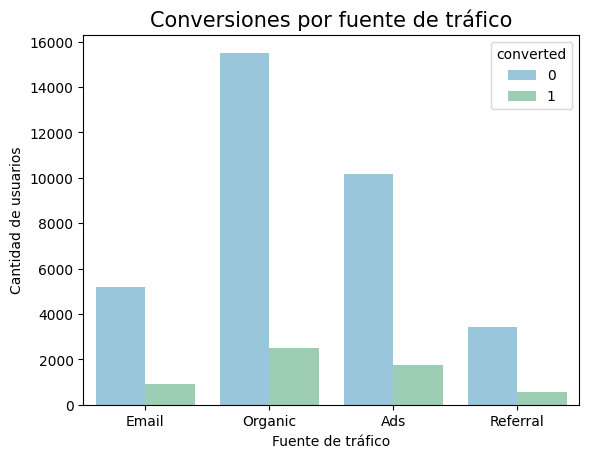

In [67]:
sns.countplot(
    data=df,
    x='traffic_source',
    hue='converted',
    palette=['#8ecae6', '#95d5b2']
)

plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico')
plt.ylabel('Cantidad de usuarios')
plt.show()

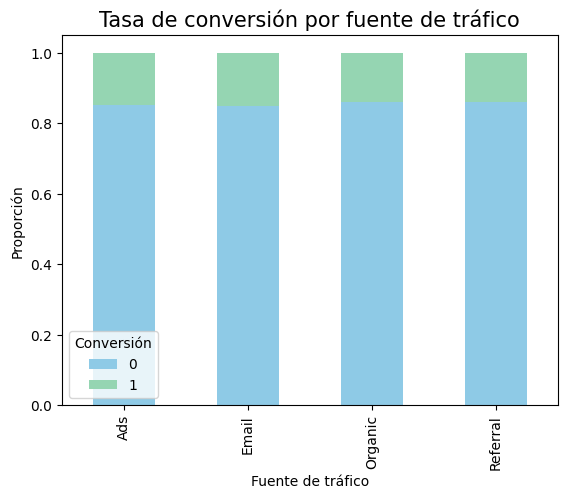

In [68]:
tabla_normalizada = pd.crosstab(
    df['traffic_source'],
    df['converted'],
    normalize='index'
)

tabla_normalizada.plot(
    kind='bar',
    stacked=True,
    color=['#8ecae6', '#95d5b2']
)

plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico')
plt.ylabel('Proporción')
plt.legend(title='Conversión')
plt.show()

El gráfico de cantidades absolutas muestra que la fuente de tráfico Organic genera el mayor volumen de usuarios y también el mayor número de conversiones, seguida por Ads, Email y Referral. Sin embargo, al analizar las proporciones de conversión, se observa que las diferencias entre los canales son relativamente pequeñas, aunque Email presenta una tasa de conversión ligeramente superior. Estos resultados coinciden con la prueba Chi-cuadrada, que encontró una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (p < 0.05). Por lo tanto, el canal de adquisición parece influir en la probabilidad de conversión, aunque el efecto observado es moderado.

### Relación entre el tipo de usuario y la conversión

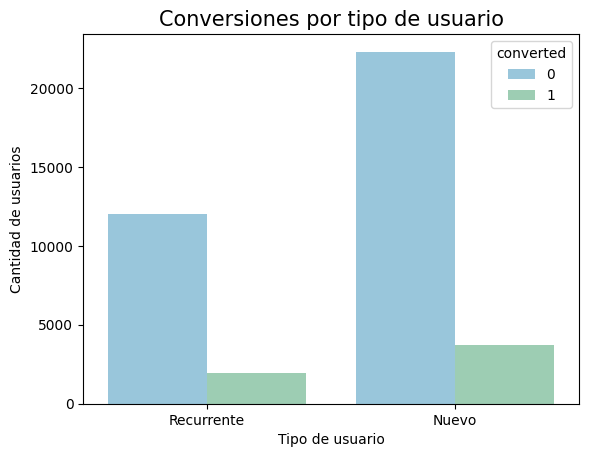

In [69]:
sns.countplot(
    data=df,
    x='user_type',
    hue='converted',
    palette=['#8ecae6', '#95d5b2']
)

plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario')
plt.ylabel('Cantidad de usuarios')
plt.show()

El gráfico muestra que los usuarios nuevos representan la mayor parte del tráfico y, en consecuencia, también generan un mayor número absoluto de conversiones. Sin embargo, las cantidades absolutas no permiten determinar si un tipo de usuario es más propenso a convertir que otro, por lo que es necesario analizar las proporciones de conversión.

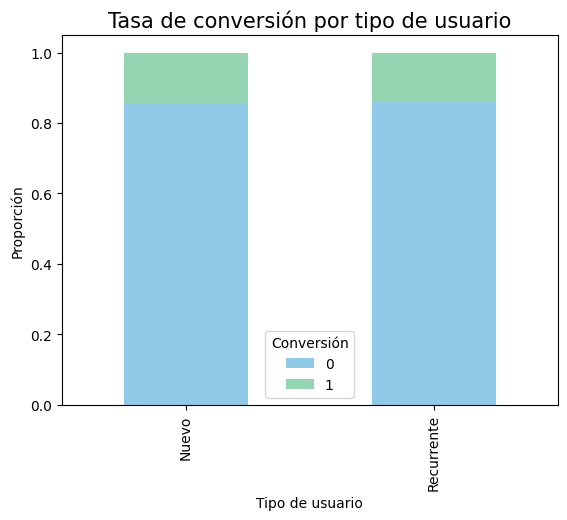

In [70]:
tabla_usuario_norm = pd.crosstab(
    df['user_type'],
    df['converted'],
    normalize='index'
)

tabla_usuario_norm.plot(
    kind='bar',
    stacked=True,
    color=['#8ecae6', '#95d5b2']
)

plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario')
plt.ylabel('Proporción')
plt.legend(title='Conversión')
plt.show()

Las tasas de conversión de los usuarios nuevos y recurrentes son muy similares, con diferencias mínimas entre ambos grupos. Esta observación coincide con los resultados de la prueba Chi-cuadrada, que no encontró evidencia estadísticamente significativa de una asociación entre el tipo de usuario y la conversión (p = 0.474). Por lo tanto, el tipo de usuario no parece influir de manera relevante en la probabilidad de conversión dentro de este experimento.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La prueba t arrojó un estadístico de -9.37 y un valor p de 1.06 × 10⁻²⁰.
- Se encontraron diferencias estadísticamente significativas en el gasto promedio entre las versiones A y B.
- **Interpretación:** La versión B genera un mayor valor económico por usuario convertido, por lo que muestra un mejor desempeño en términos de ingresos.

<br>

**Tasa de conversión:** 
- La página A registró 2.512 conversiones de 19.982 usuarios (12.57%).
- La página B registró 3.194 conversiones de 20.018 usuarios (15.96%).
- **Interpretación:** La página B presenta una tasa de conversión significativamente superior a la página A, convirtiendo aproximadamente 3.4 puntos porcentuales más de usuarios.

---

#### 📊 **Segmentación por fuente de tráfico**
- La prueba Chi-cuadrada encontró una asociación significativa entre la fuente de tráfico y la conversión (χ² = 8.66; p = 0.034).
- Organic generó el mayor número de conversiones (2.480), seguido de Ads (1.759), Email (918) y Referral (549).
- **Interpretación:** La fuente de tráfico influye en la probabilidad de conversión. Los resultados sugieren que algunos canales son más efectivos que otros para atraer usuarios que terminan convirtiendo.
 
 ---

#### 📊 **Segmentación por tipo de usuario**
- La prueba Chi-cuadrada no encontró evidencia de asociación entre el tipo de usuario y la conversión (χ² = 0.51; p = 0.474).
- Los usuarios nuevos presentaron una tasa de conversión de 14.36%, mientras que los recurrentes registraron 14.09%.
- **Interpretación:** No existen diferencias estadísticamente significativas en la conversión entre usuarios nuevos y recurrentes. El comportamiento de ambos grupos es prácticamente equivalente.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Implementar la versión B de la landing page, ya que genera una tasa de conversión significativamente mayor y un mayor gasto promedio por usuario convertido.
- Priorizar la inversión en los canales de tráfico con mejor desempeño, especialmente Organic y aquellos que presenten mayores tasas de conversión, para maximizar el retorno de las acciones de marketing.
- Mantener una estrategia unificada para usuarios nuevos y recurrentes, ya que no se encontraron diferencias significativas en su comportamiento de conversión.
- Continuar realizando experimentos A/B para optimizar la experiencia de usuario y aumentar tanto la conversión como el valor económico generado por cada visitante.